In [1]:
# Download Packages
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import annoy

from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sc.set_figure_params(figsize=(5,5)) # no blurry figures allowed

In [2]:
# Load ATAC high-quality-rna-filtered samples
atac_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/atac_filtered/'

nk_sfd_atac = sc.read_h5ad(atac_dir + 'NK_SFD_atac.h5ad')
nk_hfd_atac = sc.read_h5ad(atac_dir + 'NK_HFD_atac.h5ad')
nk_glp_atac = sc.read_h5ad(atac_dir + 'NK_GLP_atac.h5ad')
nk_cr_atac  = sc.read_h5ad(atac_dir + 'NK_CR_atac.h5ad')


Sample  N Cells  CR FRiP  Atlas FRiP  Delta
NK_SFD     3834    0.717       0.777  0.060
NK_HFD     4681    0.704       0.777  0.073
NK_GLP     6295    0.708       0.785  0.076
 NK_CR     3148    0.685       0.768  0.083


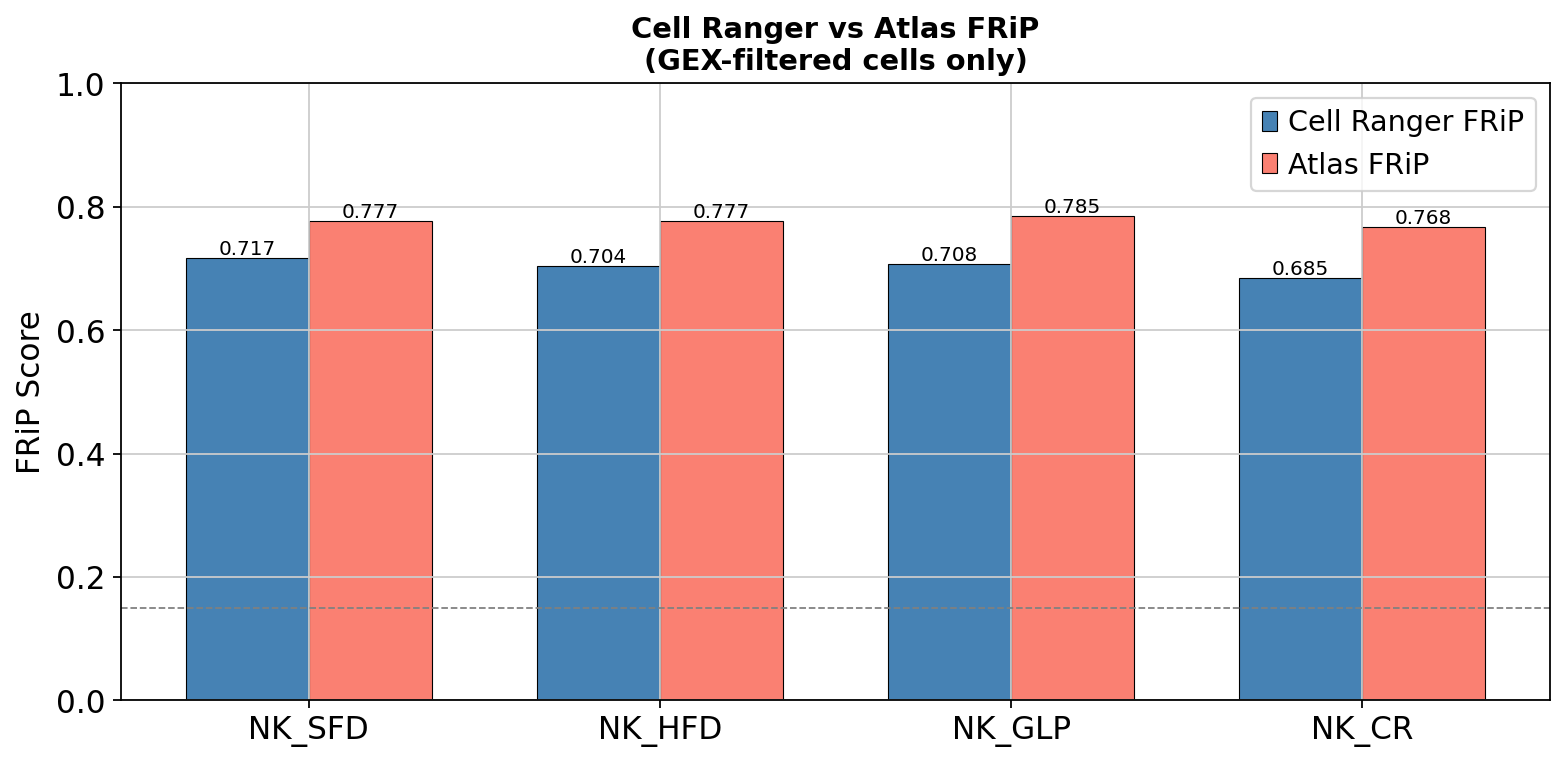

In [3]:
# Compare Cell Ranger FRiP vs Atlas FRiP for GEX-filtered cells across all conditions
cr_base     = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/cr_arc_outputs/'
barcode_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/barcodes/'

cr_samples = {
    'NK_SFD': 'NK_1-SFD',
    'NK_HFD': 'NK_2-HFD',
    'NK_GLP': 'NK_3-HFD_GLP',
    'NK_CR':  'NK_4-HFD_CR',
}

atac_objects = {
    'NK_SFD': nk_sfd_atac,
    'NK_HFD': nk_hfd_atac,
    'NK_GLP': nk_glp_atac,
    'NK_CR':  nk_cr_atac,
}

records = []
for short_name, cr_name in cr_samples.items():
    per_barcode = pd.read_csv(f'{cr_base}{cr_name}/outs/per_barcode_metrics.csv')
    barcodes    = pd.read_csv(f'{barcode_dir}{short_name}_barcodes.txt',
                              header=None, names=['barcode'])
    pb          = per_barcode[per_barcode['barcode'].isin(barcodes['barcode'])]
    cr_frip    = pb['atac_peak_region_fragments'].sum() / max(pb['atac_fragments'].sum(), 1)
    atlas_frip = atac_objects[short_name].obs['FRiP'].median()
    records.append({
        'Sample':     short_name,
        'N Cells':    len(pb),
        'CR FRiP':    round(cr_frip,    3),
        'Atlas FRiP': round(atlas_frip, 3),
        'Delta':      round(atlas_frip - cr_frip, 3),
    })

comparison_df = pd.DataFrame(records)
print(comparison_df.to_string(index=False))

# Plot
samples = comparison_df['Sample'].tolist()
x       = np.arange(len(samples))
width   = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# top panel: CR vs Atlas FRiP
bars_cr    = ax1.bar(x - width/2, comparison_df['CR FRiP'],    width, label='Cell Ranger FRiP', color='steelblue', edgecolor='black', linewidth=0.5)
bars_atlas = ax1.bar(x + width/2, comparison_df['Atlas FRiP'], width, label='Atlas FRiP',       color='salmon',    edgecolor='black', linewidth=0.5)

for bar in bars_cr:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars_atlas:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(samples)
ax1.set_ylabel('FRiP Score')
ax1.set_ylim(0, 1.0)
ax1.set_title('Cell Ranger vs Atlas FRiP\n(GEX-filtered cells only)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.axhline(0.15, c='grey', linestyle='--', linewidth=0.8)

# bottom panel: delta (Atlas FRiP - CR FRiP)
bars_delta = ax2.bar(samples, comparison_df['Delta'], color='seagreen', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars_delta, comparison_df['Delta']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'+{val:.3f}', ha='center', fontsize=9)

ax2.set_ylabel('Atlas FRiP − CR FRiP')
ax2.set_ylim(0, max(comparison_df['Delta']) * 1.3)
ax2.set_title('FRiP Gain from NK Atlas vs Cell Ranger Peaks', fontsize=13, fontweight='bold')
ax2.axhline(0, c='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('frip_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Investigating Structure of ATAC Data
for name, adata in [('NK_SFD', nk_sfd_atac), ('NK_HFD', nk_hfd_atac), 
                    ('NK_GLP', nk_glp_atac), ('NK_CR',  nk_cr_atac)]:
    print(f"\n--- {name} ---")
    print(adata)
    print(adata.var.iloc[:3, :5].to_string())
    print("\nPeak matrix (5 cells x 5 peaks):")
    print(pd.DataFrame(
        adata.X[:5, :5].toarray(),
        index=adata.obs_names[:5],
        columns=adata.var_names[:5]
    ).to_string())
    print("\nQC metrics (5 cells):")
    print(adata.obs.iloc[:5].to_string())


--- NK_SFD ---
AnnData object with n_obs × n_vars = 3834 × 180190
    obs: 'barcode', 'sample', 'condition', 'total_insertions', 'peak_insertions', 'FRiP', 'nucleosomal_signal', 'n_counts', 'n_features_per_cell', 'tsse'
    var: 'chr', 'start', 'end', 'peak_id', 'source', 'type', 'interval'
                chr   start     end peak_id source
peak_id                                           
peak1    GL456211.1  104115  104252   peak1      .
peak2    GL456211.1  112079  112623   peak2      .
peak3    GL456211.1  112757  113177   peak3      .

Peak matrix (5 cells x 5 peaks):
peak_id                    peak1  peak2  peak3  peak4  peak5
NK_SFD:AAACAGCCACCTAAGC-1      0      0      0      0      0
NK_SFD:AAACAGCCAGATTCAT-1      0      0      0      0      0
NK_SFD:AAACATGCAAGGCCAA-1      0      0      0      0      0
NK_SFD:AAACATGCACAACAAA-1      0      0      0      0      0
NK_SFD:AAACCGAAGCTCATAA-1      0      0      0      0      0

QC metrics (5 cells):
                             

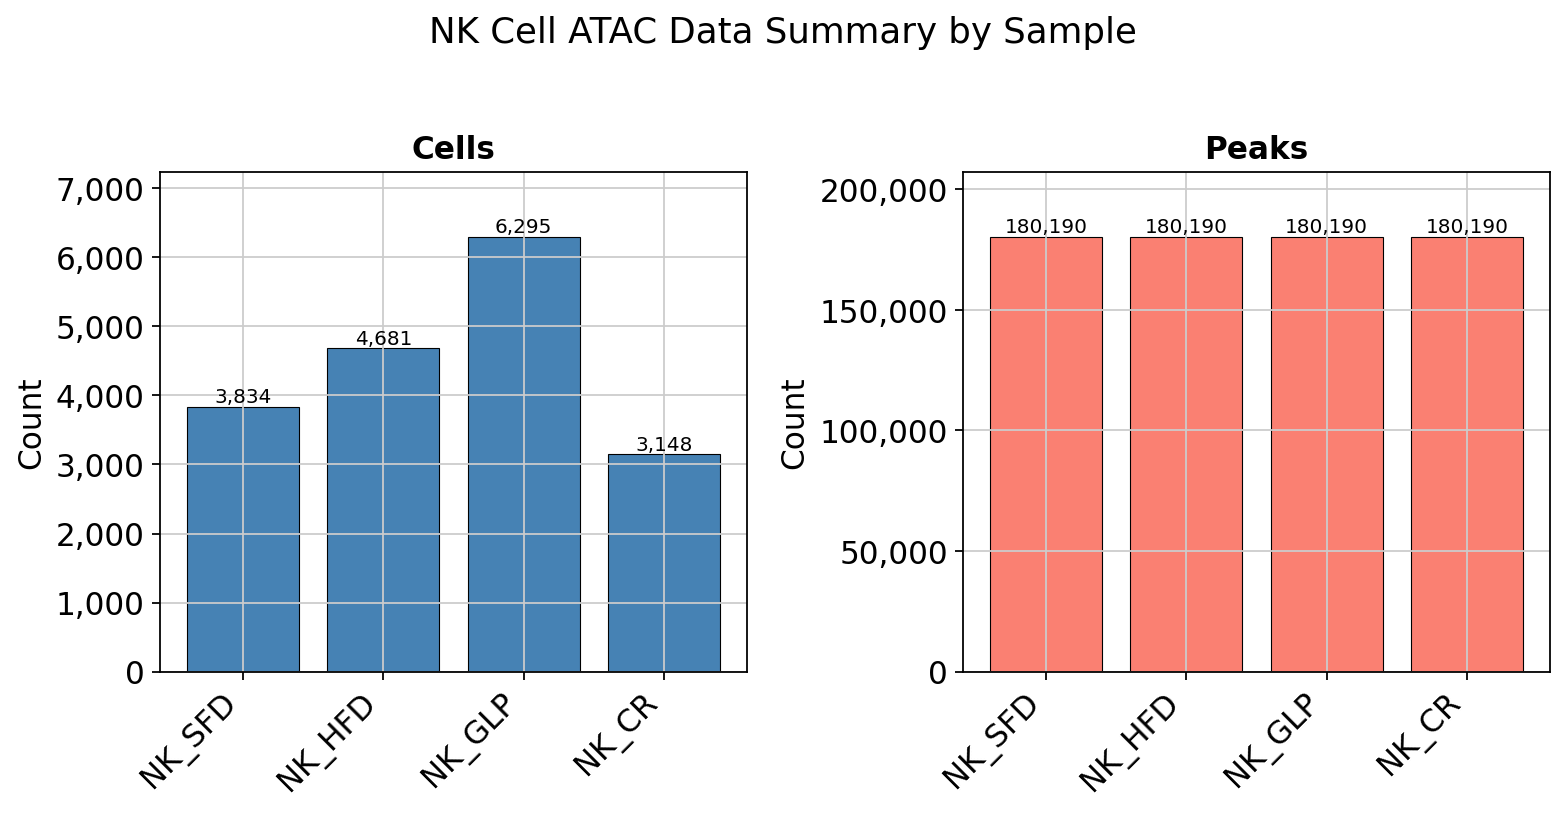

In [5]:
# Bar plot with # of cells and peaks per ATAC sample
samples = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
atac_objects = [nk_sfd_atac, nk_hfd_atac, nk_glp_atac, nk_cr_atac]

cells = [adata.n_obs  for adata in atac_objects]
peaks = [adata.n_vars for adata in atac_objects]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

metrics = [
    ('Cells', cells, 'steelblue'),
    ('Peaks', peaks, 'salmon'),
]

for ax, (title, values, color) in zip(axes, metrics):
    ax.bar(samples, values, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(samples, rotation=45, ha='right')
    ax.set_ylim(0, max(values) * 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    for i, v in enumerate(values):
        ax.text(i, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('NK Cell ATAC Data Summary by Sample', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('atac_sample_summary_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

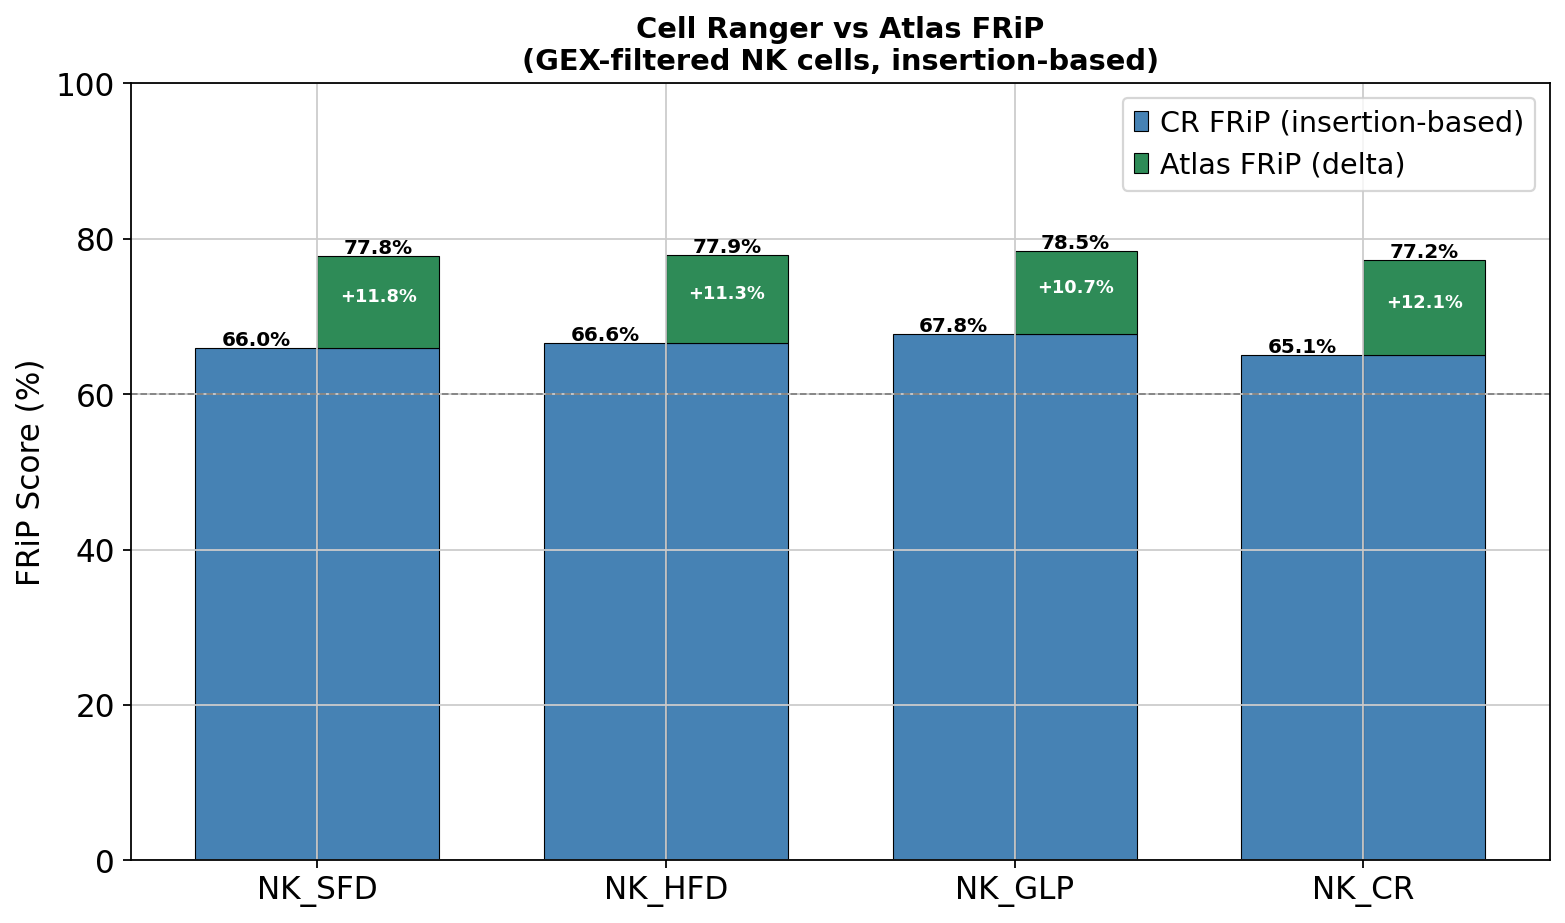

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# CR FRiP scores (insertion-based, from 021_cr_frip_comparison.py)
cr_frip = {
    'NK_SFD': 0.660,
    'NK_HFD': 0.666,
    'NK_GLP': 0.678,
    'NK_CR':  0.651,
}

# Atlas FRiP scores (median per sample from h5ad obs)
atlas_frip = {name: adata.obs['FRiP'].median() for name, adata in samples_atac_filtered.items()}

samples = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
cr_vals    = [cr_frip[s] * 100    for s in samples]
atlas_vals = [atlas_frip[s] * 100 for s in samples]
deltas     = [atlas_vals[i] - cr_vals[i] for i in range(len(samples))]

x     = np.arange(len(samples))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# CR FRiP bars
bars_cr = ax.bar(x - width/2, cr_vals, width,
                 label='CR FRiP (insertion-based)',
                 color='steelblue', edgecolor='black', linewidth=0.5)

# Atlas base + delta on top
ax.bar(x + width/2, cr_vals, width,
       color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, deltas, width, bottom=cr_vals,
       label='Atlas FRiP (delta)',
       color='seagreen', edgecolor='black', linewidth=0.5)

# value labels
for i, (bar, val) in enumerate(zip(bars_cr, cr_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

for i, (val, delta) in enumerate(zip(atlas_vals, deltas)):
    ax.text(x[i] + width/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(x[i] + width/2, cr_vals[i] + delta/2,
            f'+{delta:.1f}%', ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_ylabel('FRiP Score (%)')
ax.set_ylim(0, 100)
ax.set_title('Cell Ranger vs Atlas FRiP\n(GEX-filtered NK cells, insertion-based)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(60, c='grey', linestyle='--', linewidth=0.8, label='min threshold (60%)')

plt.tight_layout()
plt.savefig('/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/atac_filtered/frip_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Helper ATAC QC Functions:

def atac_qc(adata, sample_name):
    metrics = ['total_insertions', 'n_features_per_cell', 'FRiP', 'tsse', 'nucleosomal_signal']
    labels  = ['Total Insertions', 'Features Per Cell', 'FRiP', 'TSS Enrichment', 'Nucleosomal Signal']
    ax = sc.pl.violin(adata, metrics, multi_panel=True, stripplot=False, show=False)
    for a, label in zip(ax.axes.flat, labels):
        a.set_title(label)
        a.set_xlabel(label)
    plt.suptitle(f'{sample_name} ATAC QC Metrics', fontsize=14, fontweight='bold', y=1.02)
    plt.show()

# compute global axis limits using 99.5th percentile to avoid extreme outlier stretching
global_limits = {
    'total_insertions':    (0, max(np.percentile(adata.obs['total_insertions'], 99.5) for adata in samples_atac.values())),
    'FRiP':                (0, 1.0),
    'tsse':                (0, max(np.percentile(adata.obs['tsse'], 99.5) for adata in samples_atac.values())),
    'nucleosomal_signal':  (0, max(np.percentile(adata.obs['nucleosomal_signal'], 99.5) for adata in samples_atac.values())),
    'n_features_per_cell': (0, max(np.percentile(adata.obs['n_features_per_cell'], 99.5) for adata in samples_atac.values())),
}

print("Global axis limits:")
for k, v in global_limits.items():
    print(f"  {k}: {v}")
def atac_qc2(adata, sample_name, min_insertions, max_insertions, min_frip, 
             min_tsse, max_nucleosomal, global_limits=None):
    # flags cells failing any threshold and plots distributions with threshold lines
    # all metrics are independent so all thresholds are set and flagged simultaneously
    adata.obs["low_insertions"]   = adata.obs["total_insertions"]   < min_insertions
    adata.obs["high_insertions"]  = adata.obs["total_insertions"]   > max_insertions
    adata.obs["low_frip"]         = adata.obs["FRiP"]               < min_frip
    adata.obs["low_tsse"]         = adata.obs["tsse"]               < min_tsse
    adata.obs["high_nucleosomal"] = adata.obs["nucleosomal_signal"] > max_nucleosomal

    fig, axes = plt.subplots(1, 5, figsize=(25, 4))
    fig.suptitle(f'{sample_name} ATAC QC Thresholds', fontsize=14, fontweight='bold')

    # total insertions histogram
    axes[0].hist(adata.obs['total_insertions'], bins=500, color='steelblue', edgecolor='black', linewidth=0.3)
    axes[0].axvline(min_insertions, c='r', linestyle='--', label=f'min={min_insertions:,}')
    axes[0].axvline(max_insertions, c='b', linestyle='--', label=f'max={max_insertions:,}')
    axes[0].set_xlabel('Total Insertions')
    axes[0].set_ylabel('Cell Count')
    axes[0].set_title('Total Insertions')
    axes[0].legend(fontsize=7)

    # FRiP histogram
    axes[1].hist(adata.obs['FRiP'], bins=100, color='salmon', edgecolor='black', linewidth=0.3)
    axes[1].axvline(min_frip, c='r', linestyle='--', label=f'min={min_frip}')
    axes[1].set_xlabel('FRiP')
    axes[1].set_ylabel('Cell Count')
    axes[1].set_title('FRiP')
    axes[1].legend(fontsize=7)

    # TSS enrichment histogram
    axes[2].hist(adata.obs['tsse'], bins=100, color='mediumpurple', edgecolor='black', linewidth=0.3)
    axes[2].axvline(min_tsse, c='r', linestyle='--', label=f'min={min_tsse}')
    axes[2].set_xlabel('TSS Enrichment Score')
    axes[2].set_ylabel('Cell Count')
    axes[2].set_title('TSS Enrichment')
    axes[2].legend(fontsize=7)

    # nucleosomal signal histogram
    axes[3].hist(adata.obs['nucleosomal_signal'], bins=100, color='seagreen', edgecolor='black', linewidth=0.3)
    axes[3].axvline(max_nucleosomal, c='r', linestyle='--', label=f'max={max_nucleosomal}')
    axes[3].set_xlabel('Nucleosomal Signal')
    axes[3].set_ylabel('Cell Count')
    axes[3].set_title('Nucleosomal Signal')
    axes[3].legend(fontsize=7)

    # scatter: total insertions vs features per cell colored by TSS score
    sc_plot = axes[4].scatter(
    adata.obs['total_insertions'],
    adata.obs['n_features_per_cell'],
    s=1, alpha=0.3, color='steelblue'
    )
    axes[4].axvline(min_insertions, c='r', linestyle='--')
    axes[4].axvline(max_insertions, c='b', linestyle='--')
    axes[4].set_xlabel('Total Insertions')
    axes[4].set_ylabel('Features Per Cell')
    axes[4].set_title('Insertions vs Features')

    # apply global limits BEFORE show
    if global_limits:
        axes[0].set_xlim(global_limits['total_insertions'])
        axes[1].set_xlim(global_limits['FRiP'])
        axes[2].set_xlim(global_limits['tsse'])
        axes[3].set_xlim(global_limits['nucleosomal_signal'])
        axes[4].set_xlim(global_limits['total_insertions'])
        axes[4].set_ylim(global_limits['n_features_per_cell'])

    plt.tight_layout()
    plt.show()

    # print number of cells flagged per filter
    print(f"  low_insertions:   {adata.obs['low_insertions'].sum():,} cells flagged")
    print(f"  high_insertions:  {adata.obs['high_insertions'].sum():,} cells flagged")
    print(f"  low_frip:         {adata.obs['low_frip'].sum():,} cells flagged")
    print(f"  low_tsse:         {adata.obs['low_tsse'].sum():,} cells flagged")
    print(f"  high_nucleosomal: {adata.obs['high_nucleosomal'].sum():,} cells flagged")


def atac_filter_cells(adata):
    # removes all cells flagged by atac_qc2 in a single pass
    n_start = adata.shape[0]
    print(f"Before all filters: {adata.shape}")
    adata = adata[~adata.obs["low_insertions"]]
    print(f"After low insertion filter:        {adata.shape}")
    adata = adata[~adata.obs["high_insertions"]]
    print(f"After high insertion filter:       {adata.shape}")
    adata = adata[~adata.obs["low_frip"]]
    print(f"After low FRiP filter:             {adata.shape}")
    adata = adata[~adata.obs["low_tsse"]]
    print(f"After low TSS filter:              {adata.shape}")
    adata = adata[~adata.obs["high_nucleosomal"]]
    print(f"After high nucleosomal filter:     {adata.shape}")
    print(f"Total cells removed: {n_start - adata.shape[0]:,} ({100*(n_start - adata.shape[0])/n_start:.1f}%)")
    return adata


Global axis limits:
  total_insertions: (0, np.float64(143237.53999999975))
  FRiP: (0, 1.0)
  tsse: (0, np.float32(40.397503))
  nucleosomal_signal: (0, np.float64(1.0378728423309804))
  n_features_per_cell: (0, np.float64(22772.719999999994))



=== NK_SFD ===


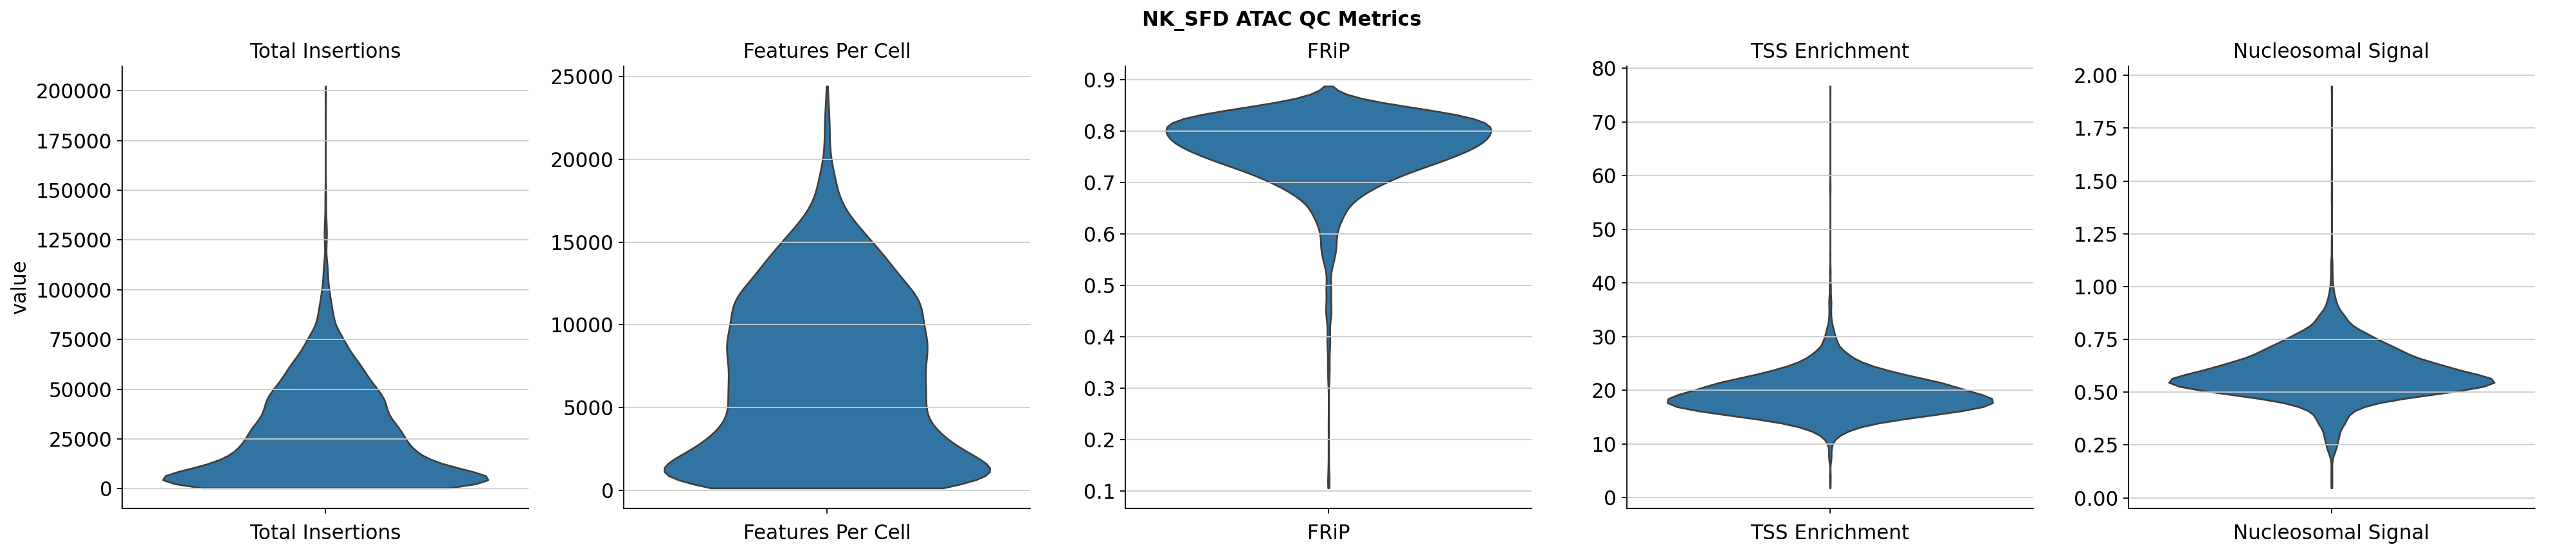


=== NK_HFD ===


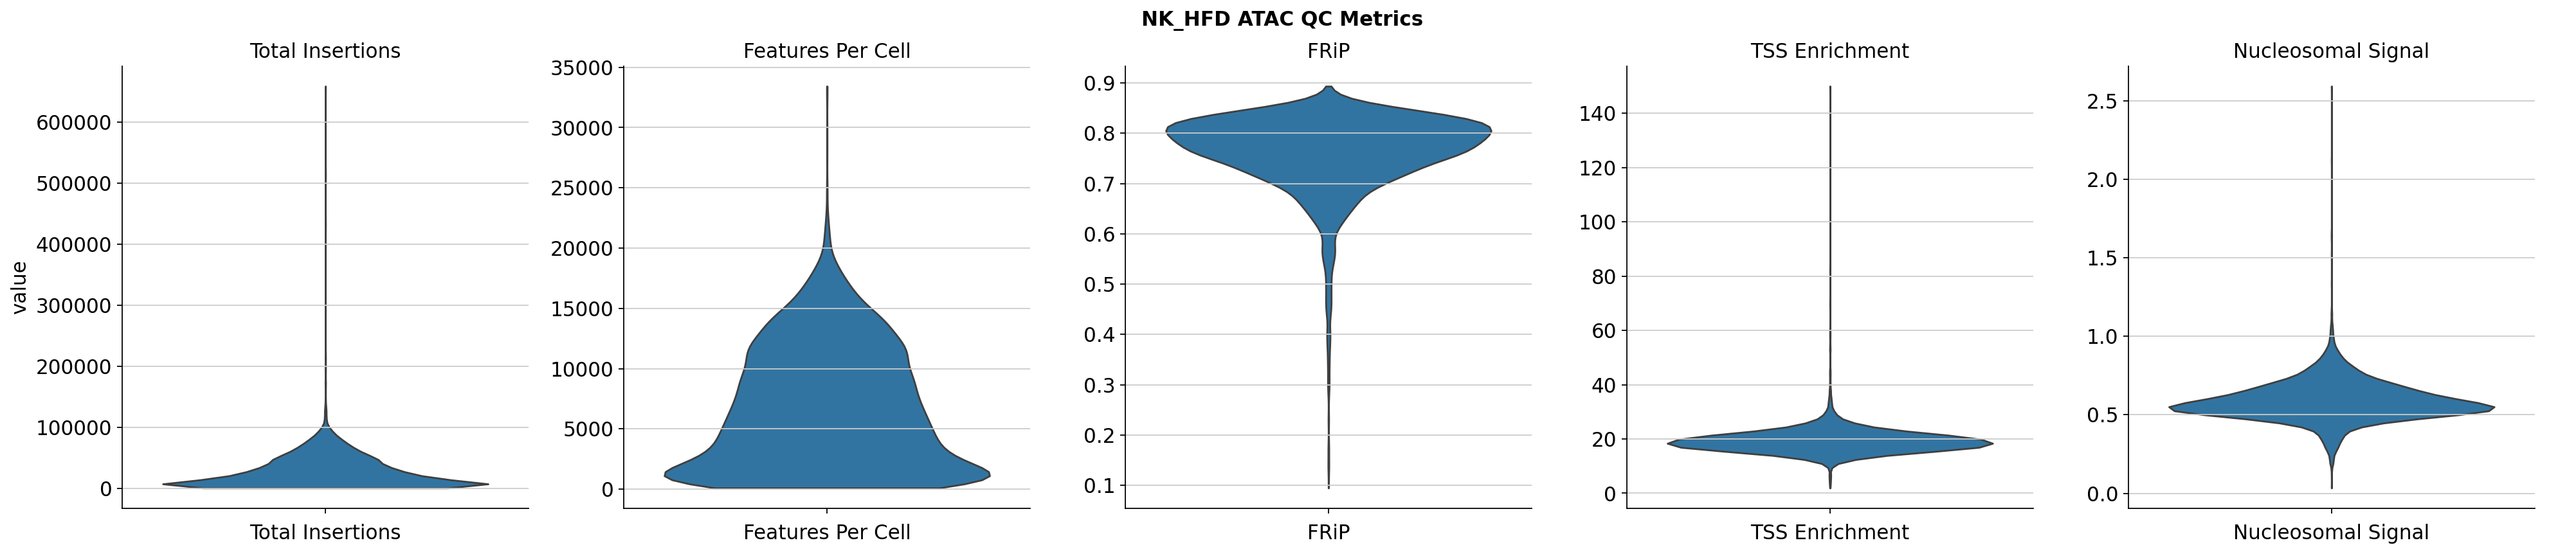


=== NK_GLP ===


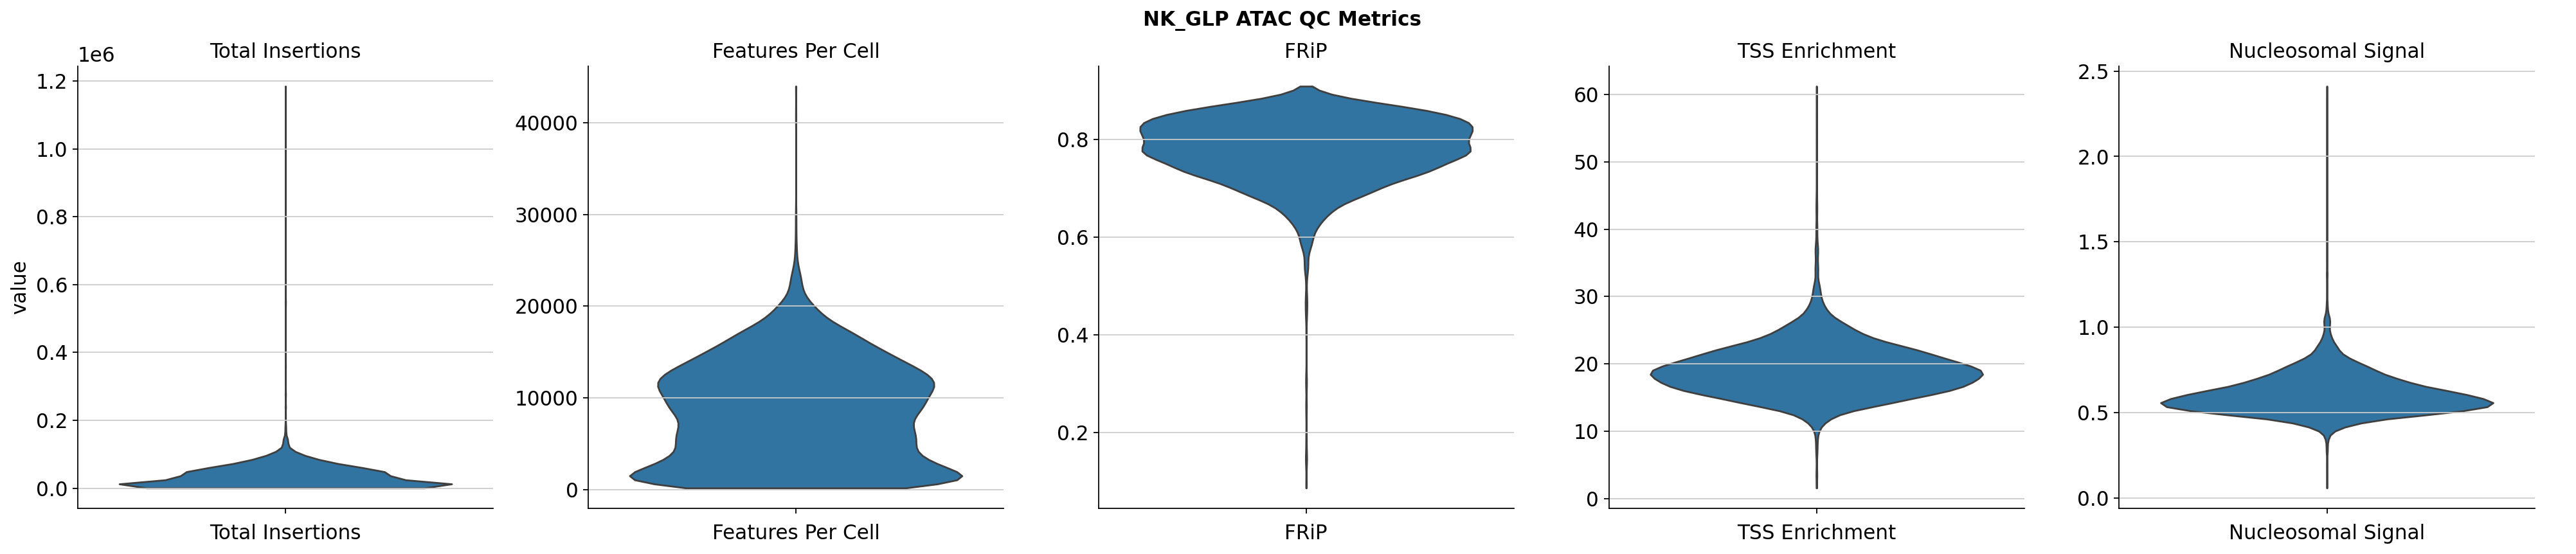


=== NK_CR ===


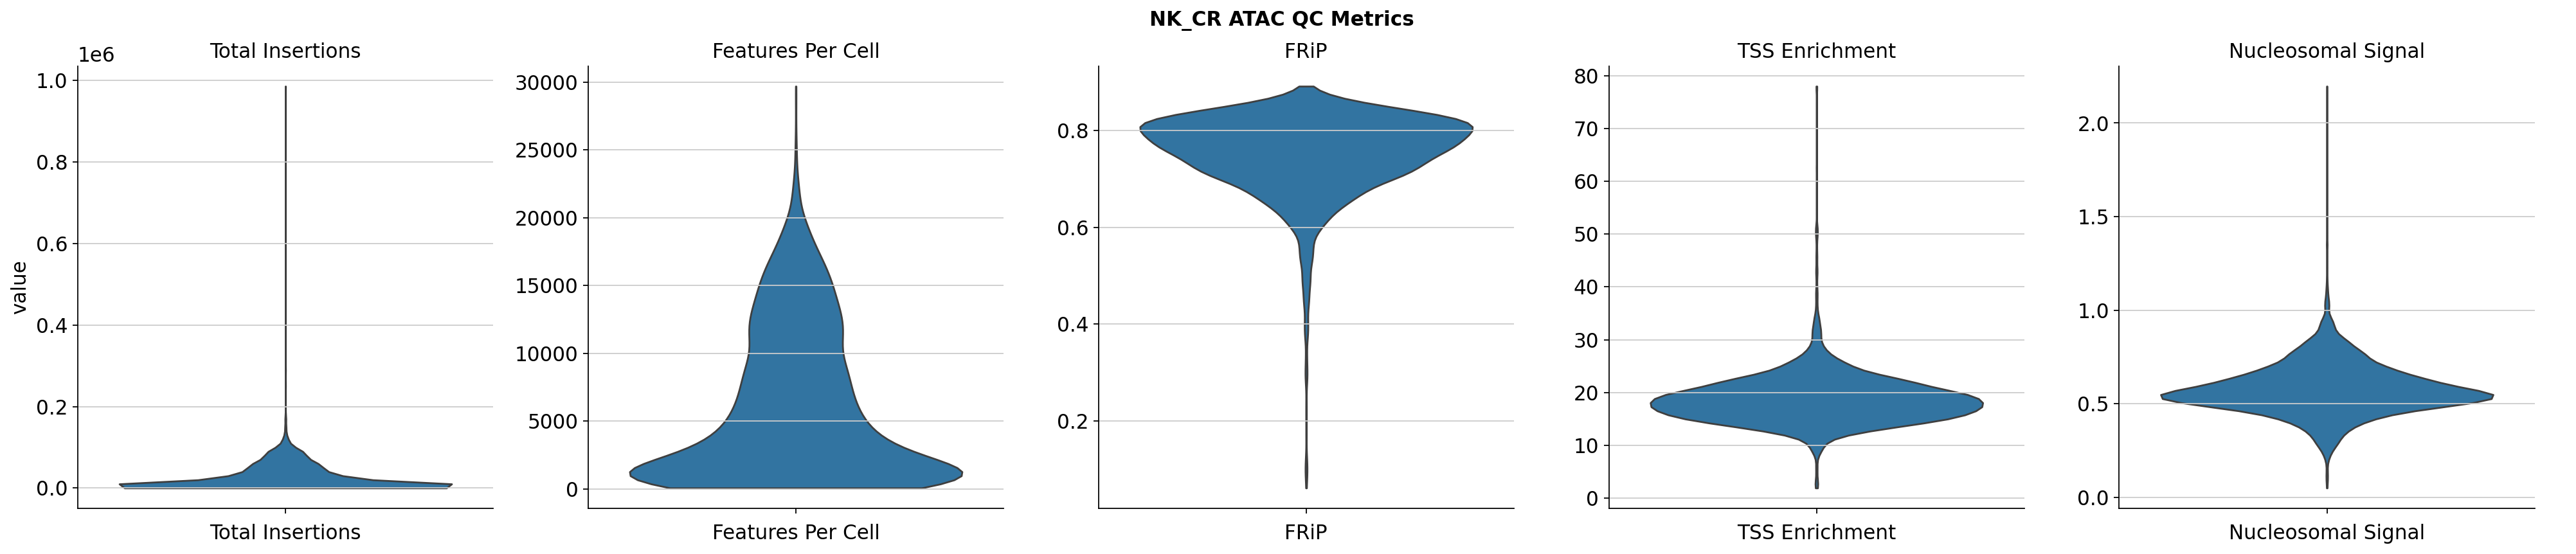

In [20]:
# Violins
samples_atac = {
    'NK_SFD': nk_sfd_atac,
    'NK_HFD': nk_hfd_atac,
    'NK_GLP': nk_glp_atac,
    'NK_CR':  nk_cr_atac,
}

for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    atac_qc(adata, name)


=== NK_SFD ===


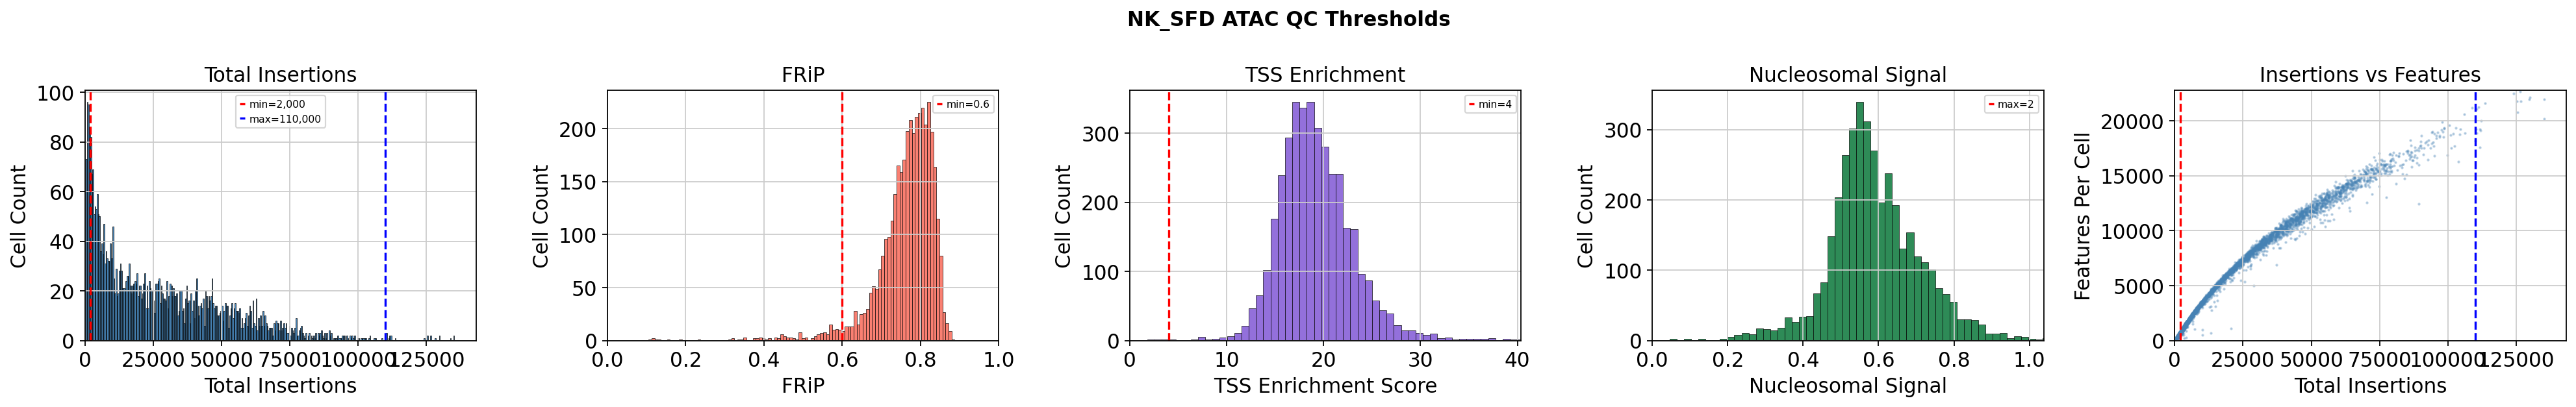

  low_insertions:   369 cells flagged
  high_insertions:  26 cells flagged
  low_frip:         146 cells flagged
  low_tsse:         3 cells flagged
  high_nucleosomal: 0 cells flagged

=== NK_HFD ===


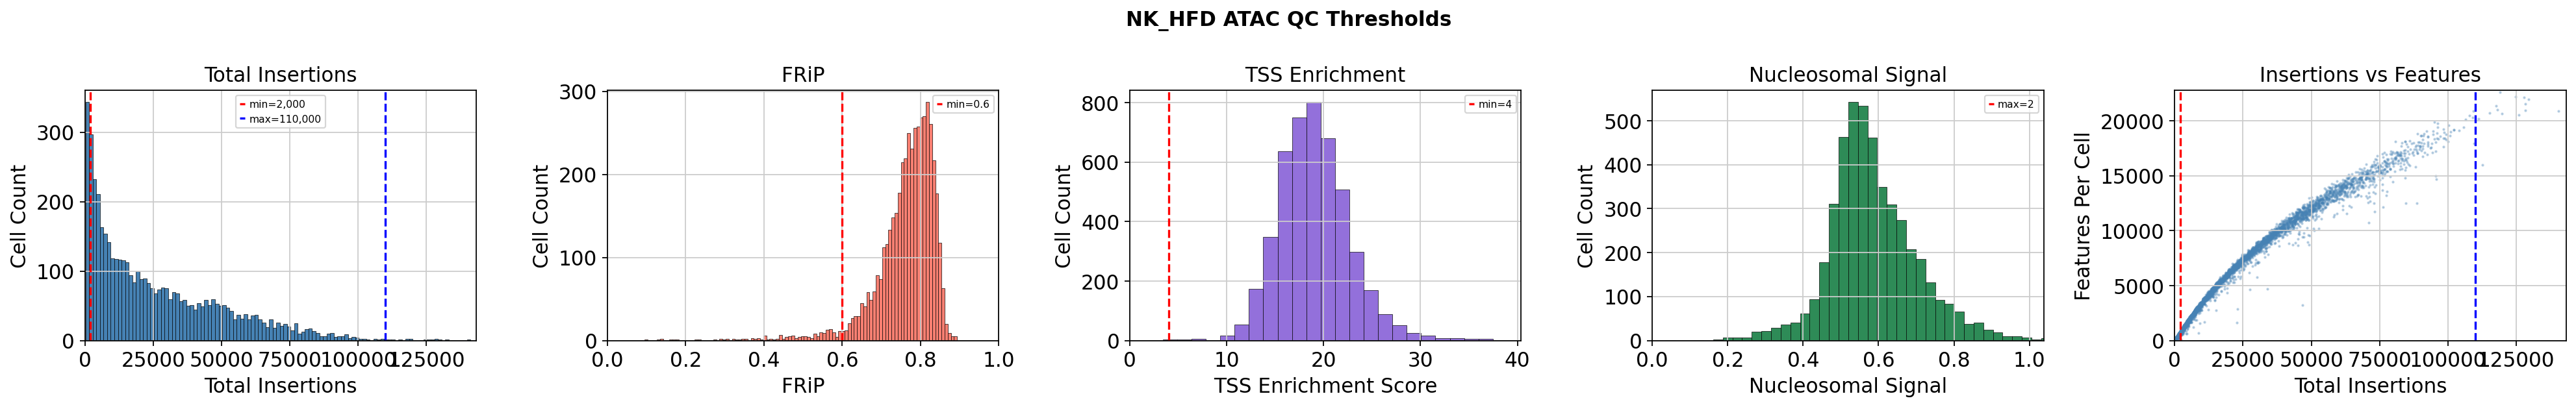

  low_insertions:   457 cells flagged
  high_insertions:  27 cells flagged
  low_frip:         179 cells flagged
  low_tsse:         3 cells flagged
  high_nucleosomal: 2 cells flagged

=== NK_GLP ===


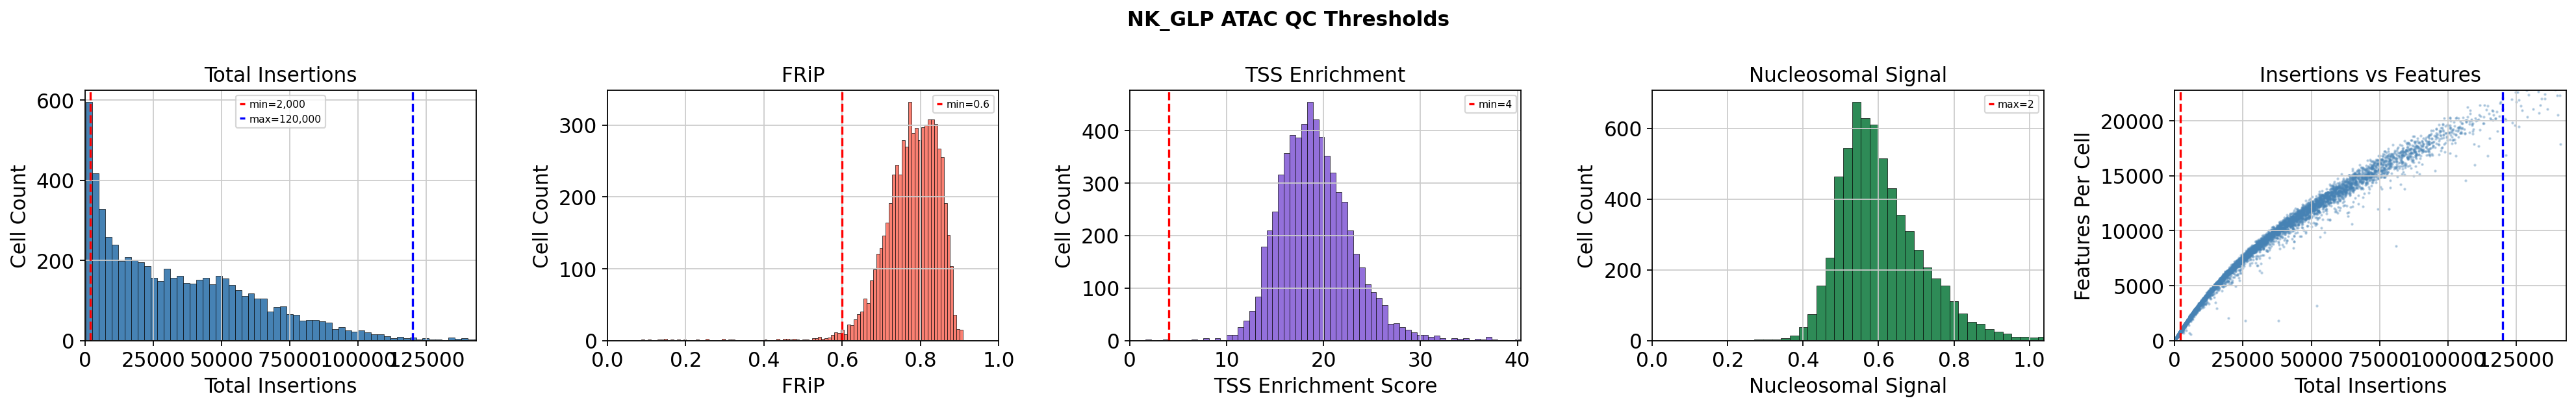

  low_insertions:   427 cells flagged
  high_insertions:  71 cells flagged
  low_frip:         83 cells flagged
  low_tsse:         5 cells flagged
  high_nucleosomal: 1 cells flagged

=== NK_CR ===


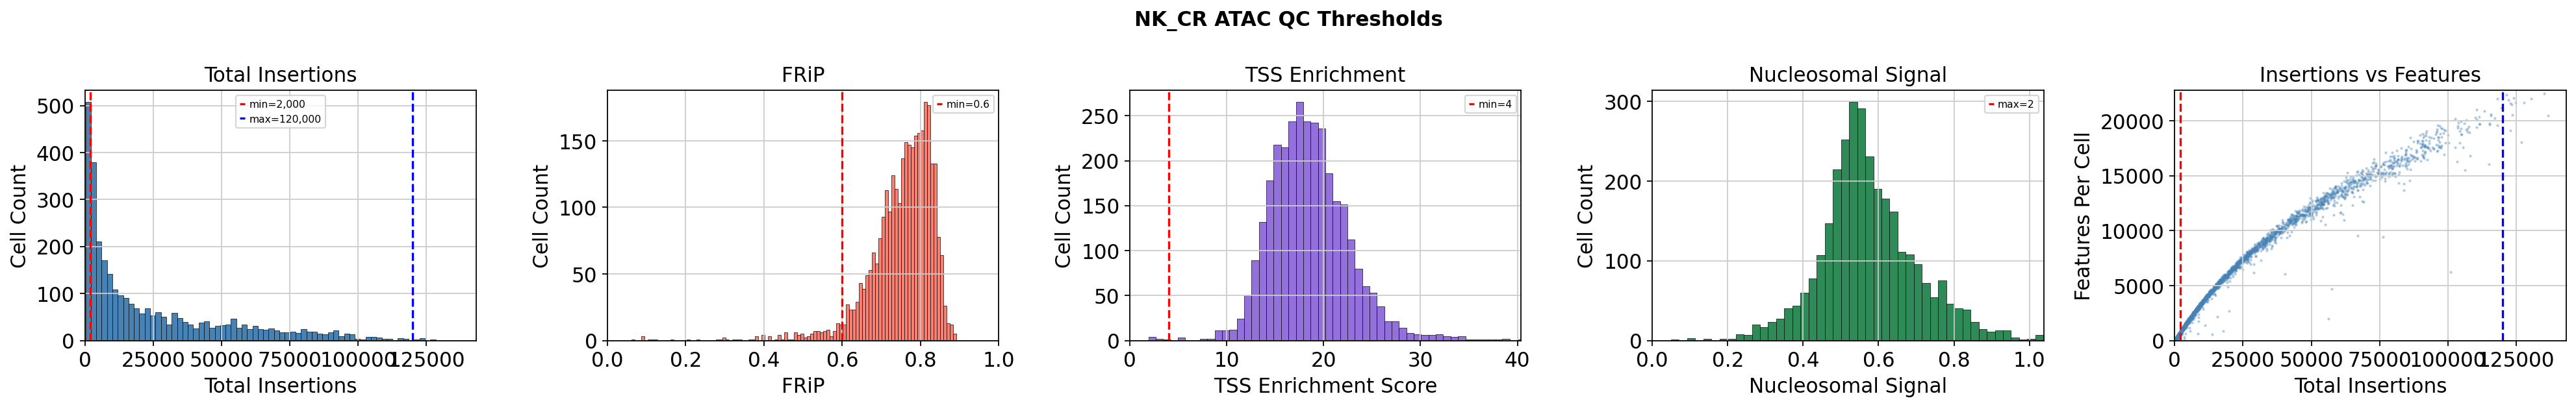

  low_insertions:   469 cells flagged
  high_insertions:  26 cells flagged
  low_frip:         136 cells flagged
  low_tsse:         7 cells flagged
  high_nucleosomal: 1 cells flagged


In [31]:
# Histograms
atac_thresholds = {
    'NK_SFD': dict(min_insertions=2000, max_insertions=110000, min_frip=0.6, min_tsse=4, max_nucleosomal=2),
    'NK_HFD': dict(min_insertions=2000, max_insertions=110000, min_frip=0.6, min_tsse=4, max_nucleosomal=2),
    'NK_GLP': dict(min_insertions=2000, max_insertions=120000, min_frip=0.6, min_tsse=4, max_nucleosomal=2),
    'NK_CR':  dict(min_insertions=2000, max_insertions=120000, min_frip=0.6, min_tsse=4, max_nucleosomal=2),
}

for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    atac_qc2(adata, name, **atac_thresholds[name], global_limits=global_limits)

In [26]:
# Exclude:
samples_atac_filtered = {}
for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    samples_atac_filtered[name] = atac_filter_cells(adata)


=== NK_SFD ===
Before all filters: (3834, 180190)
After low insertion filter:        (3465, 180190)
After high insertion filter:       (3439, 180190)
After low FRiP filter:             (3374, 180190)
After low TSS filter:              (3374, 180190)
After high nucleosomal filter:     (3374, 180190)
Total cells removed: 460 (12.0%)

=== NK_HFD ===
Before all filters: (4681, 180190)
After low insertion filter:        (4224, 180190)
After high insertion filter:       (4197, 180190)
After low FRiP filter:             (4099, 180190)
After low TSS filter:              (4099, 180190)
After high nucleosomal filter:     (4099, 180190)
Total cells removed: 582 (12.4%)

=== NK_GLP ===
Before all filters: (6295, 180190)
After low insertion filter:        (5868, 180190)
After high insertion filter:       (5797, 180190)
After low FRiP filter:             (5743, 180190)
After low TSS filter:              (5743, 180190)
After high nucleosomal filter:     (5743, 180190)
Total cells removed: 552 (8.8%)


=== NK_SFD ===


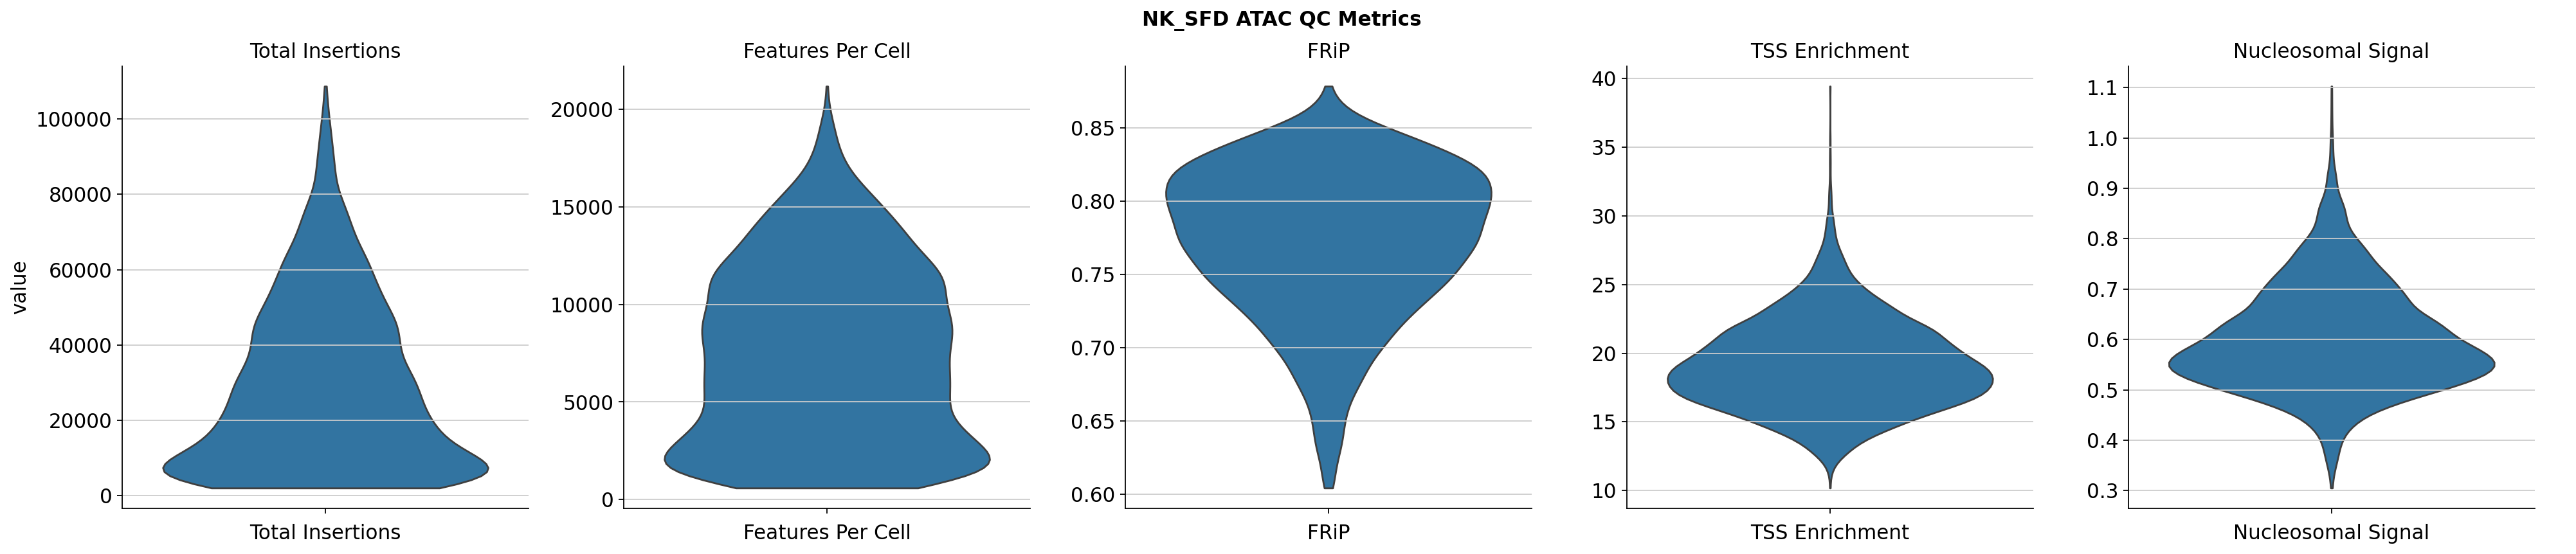


=== NK_HFD ===


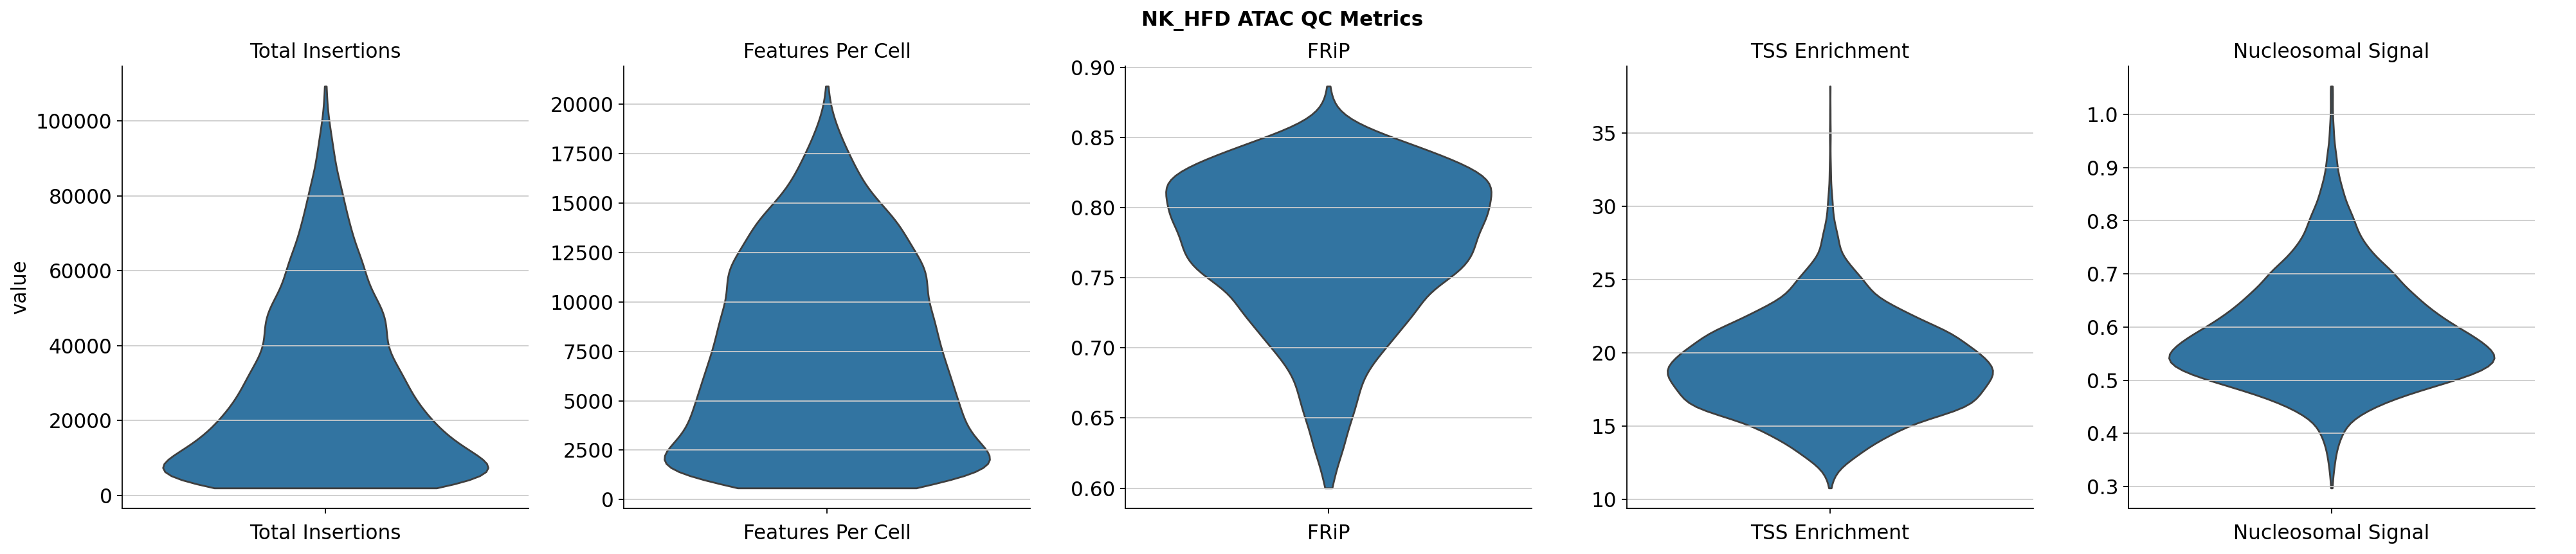


=== NK_GLP ===


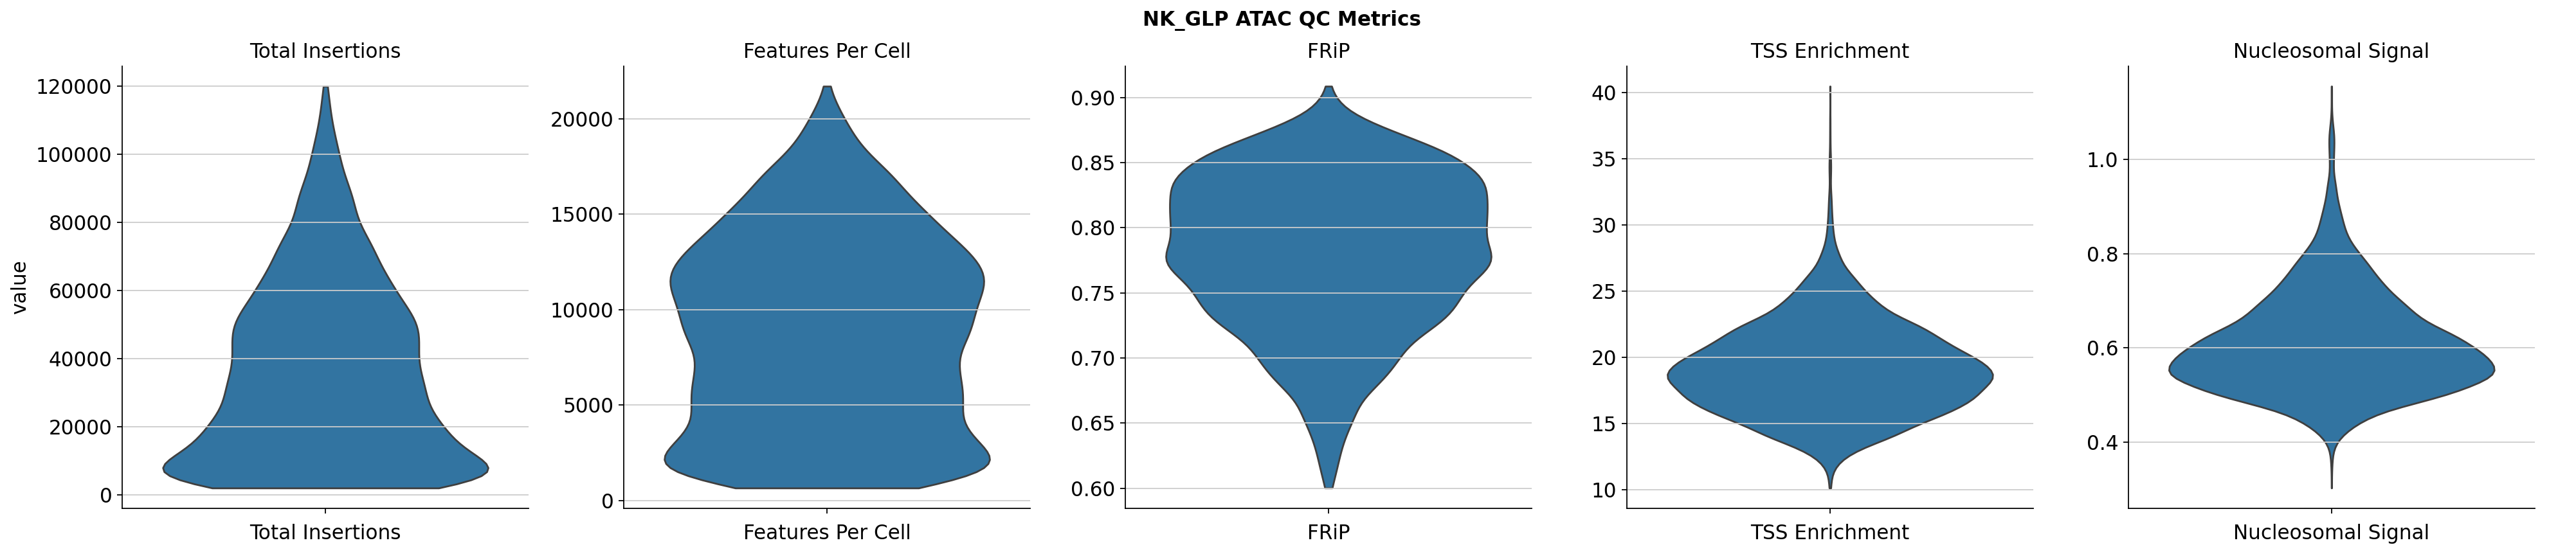


=== NK_CR ===


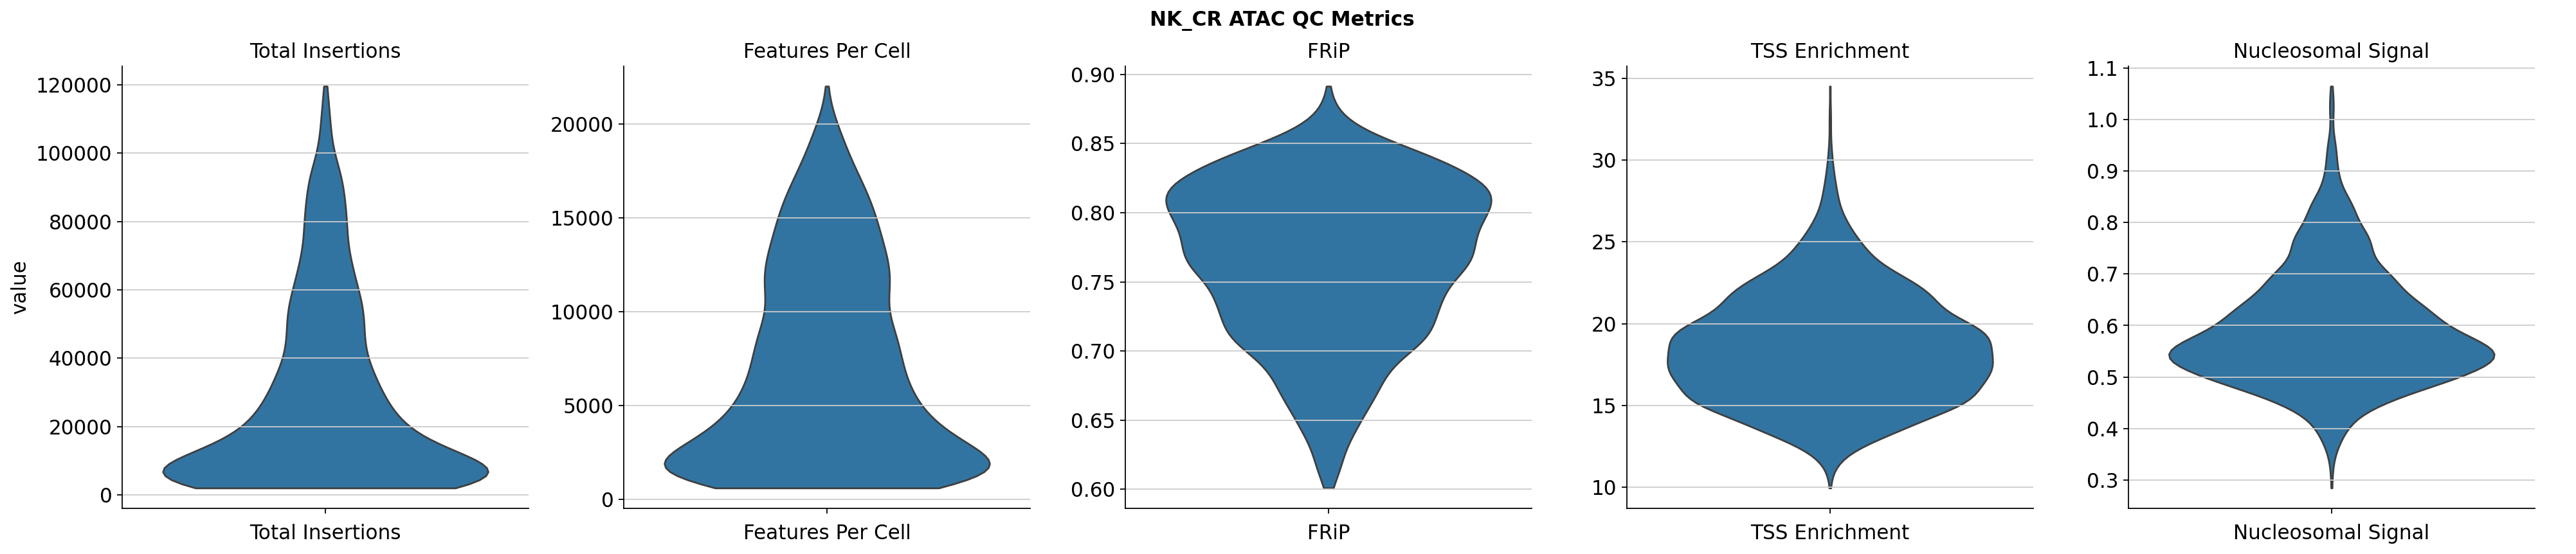

In [27]:
for name, adata in samples_atac_filtered.items():
    print(f"\n=== {name} ===")
    atac_qc(adata, name)

In [33]:
# Load GEX final filtered samples
gex_dir  = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/'
atac_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/atac_filtered/'

samples_gex_final = {
    'NK_SFD': sc.read_h5ad(gex_dir + 'NK_SFD_gex_filtered.h5ad'),
    'NK_HFD': sc.read_h5ad(gex_dir + 'NK_HFD_gex_filtered.h5ad'),
    'NK_GLP': sc.read_h5ad(gex_dir + 'NK_GLP_gex_filtered.h5ad'),
    'NK_CR':  sc.read_h5ad(gex_dir + 'NK_CR_gex_filtered.h5ad'),
}

# check barcode formats
print("GEX:", list(samples_gex_final['NK_CR'].obs_names[:3]))
print("ATAC:", list(samples_atac_filtered['NK_CR'].obs_names[:3]))

GEX: ['AAACAGCCAAGTTATC-1', 'AAACAGCCAATAACCT-1', 'AAACAGCCACAAGCCT-1']
ATAC: ['NK_CR:AAACAGCCAAGTTATC-1', 'NK_CR:AAACAGCCAATAACCT-1', 'NK_CR:AAACAGCCACAAGCCT-1']


In [35]:
# Cell Counts After Each QC Stage
raw_counts = {
    'NK_SFD': 4641,
    'NK_HFD': 5637,
    'NK_GLP': 8031,
    'NK_CR':  3625,
}

# build final joint barcode set
final_barcodes = {}
for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    gex_barcodes  = set(samples_gex_final[name].obs_names)
    atac_barcodes = set(
        bc.split(":", 1)[1] if ":" in bc else bc
        for bc in samples_atac_filtered[name].obs_names
    )
    final_barcodes[name] = gex_barcodes & atac_barcodes

# print summary table
print("=" * 75)
print(f"{'Sample':<10} {'Raw':>8} {'Post GEX':>10} {'Post ATAC':>11} {'GEX Lost':>10} {'ATAC Lost':>11} {'Total Lost':>11}")
print("=" * 75)

for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    raw       = raw_counts[name]
    post_gex  = len(samples_gex_final[name].obs_names)
    post_atac = len(final_barcodes[name])
    gex_lost  = raw - post_gex
    atac_lost = post_gex - post_atac
    total_lost = raw - post_atac
    print(f"{name:<10} {raw:>8,} {post_gex:>10,} {post_atac:>11,} {gex_lost:>10,} {atac_lost:>11,} {total_lost:>11,}")

print("=" * 75)
totals = {
    'raw':       sum(raw_counts.values()),
    'post_gex':  sum(len(samples_gex_final[n].obs_names) for n in raw_counts),
    'post_atac': sum(len(final_barcodes[n]) for n in raw_counts),
}
print(f"{'TOTAL':<10} {totals['raw']:>8,} {totals['post_gex']:>10,} {totals['post_atac']:>11,} "
      f"{totals['raw']-totals['post_gex']:>10,} {totals['post_gex']-totals['post_atac']:>11,} "
      f"{totals['raw']-totals['post_atac']:>11,}")

Sample          Raw   Post GEX   Post ATAC   GEX Lost   ATAC Lost  Total Lost
NK_SFD        4,641      3,834       3,374        807         460       1,267
NK_HFD        5,637      4,681       4,099        956         582       1,538
NK_GLP        8,031      6,295       5,743      1,736         552       2,288
NK_CR         3,625      3,148       2,608        477         540       1,017
TOTAL        21,934     17,958      15,824      3,976       2,134       6,110


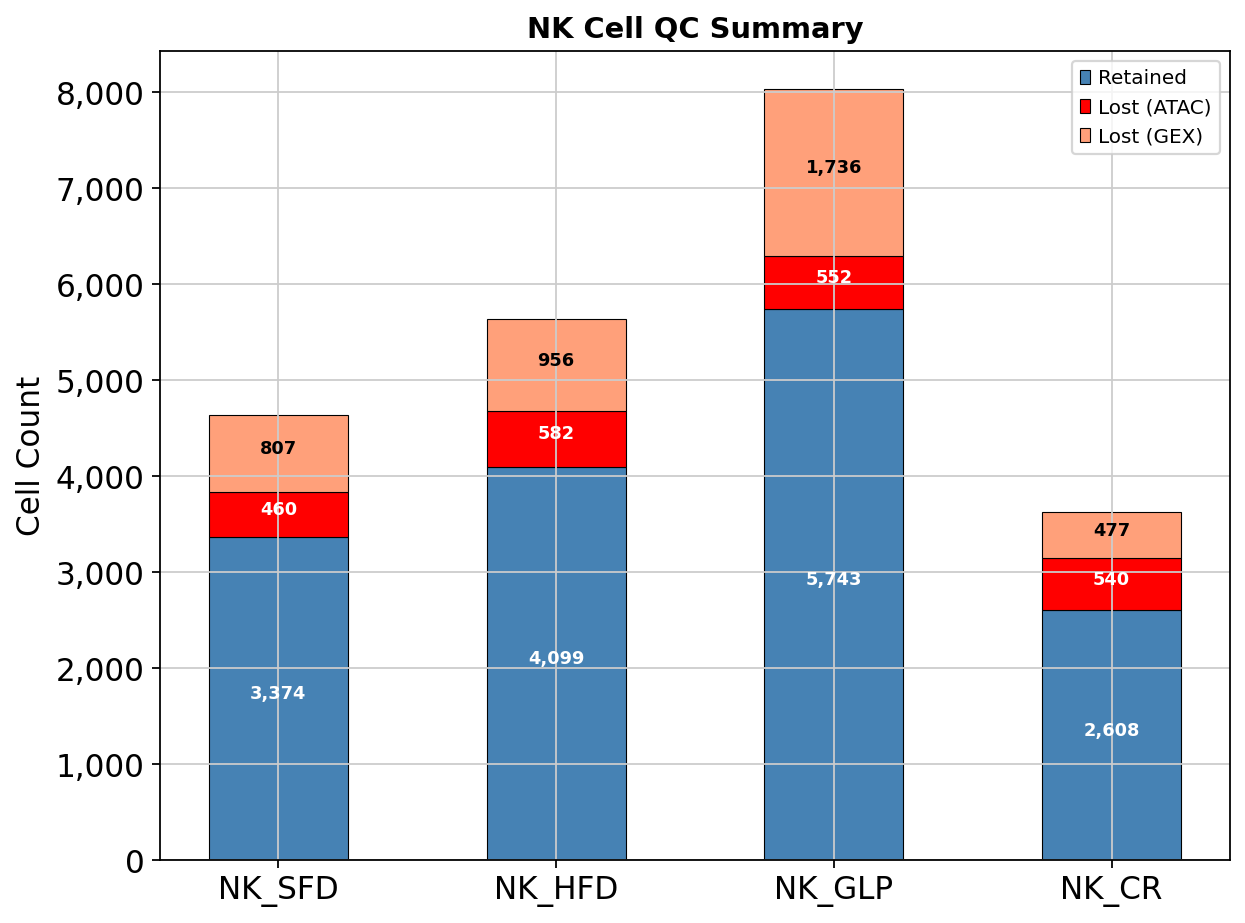

In [39]:
# Bar Plot total QC:
fig, ax = plt.subplots(figsize=(8, 6))

samples   = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
raw       = [4641, 5637, 8031, 3625]
post_gex  = [3834, 4681, 6295, 3148]
post_atac = [3374, 4099, 5743, 2608]
gex_lost  = [r - g for r, g in zip(raw, post_gex)]
atac_lost = [g - a for g, a in zip(post_gex, post_atac)]

x     = np.arange(len(samples))
width = 0.5

ax.bar(x, post_atac, width, label='Retained',    color='steelblue',   edgecolor='black', linewidth=0.5)
ax.bar(x, atac_lost, width, bottom=post_atac,    label='Lost (ATAC)', color='red',        edgecolor='black', linewidth=0.5)
ax.bar(x, gex_lost,  width, bottom=[p+a for p,a in zip(post_atac, atac_lost)],
       label='Lost (GEX)', color='lightsalmon', edgecolor='black', linewidth=0.5)

for i, (r, g, a) in enumerate(zip(raw, post_gex, post_atac)):
    ax.text(i, a/2,         f'{a:,}',   ha='center', fontsize=8, color='white', fontweight='bold')
    ax.text(i, a + (g-a)/2, f'{g-a:,}', ha='center', fontsize=8, color='white', fontweight='bold')
    ax.text(i, g + (r-g)/2, f'{r-g:,}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_ylabel('Cell Count')
ax.set_title('NK Cell QC Summary', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig('/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/atac_filtered/qc_summary_barplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Subset and output clean files with good cell set:

import os

final_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/final_filtered/'
os.makedirs(final_dir, exist_ok=True)

for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    joint = final_barcodes[name]

    # subset GEX
    gex  = samples_gex_final[name]
    gex_final = gex[gex.obs_names.isin(joint)].copy()

    # subset ATAC — need to match prefixed barcodes
    atac = samples_atac_filtered[name]
    atac_final = atac[[bc for bc in atac.obs_names if bc.split(":", 1)[1] in joint]].copy()

    # save
    gex_final.write_h5ad(final_dir + f'{name}_gex_final.h5ad')
    atac_final.write_h5ad(final_dir + f'{name}_atac_final.h5ad')

    print(f"{name}: GEX {gex_final.shape} | ATAC {atac_final.shape}")

NK_SFD: GEX (3374, 32285) | ATAC (3374, 180190)
NK_HFD: GEX (4099, 32285) | ATAC (4099, 180190)
NK_GLP: GEX (5743, 32285) | ATAC (5743, 180190)
NK_CR: GEX (2608, 32285) | ATAC (2608, 180190)


Retained: 64,511 / 180,190 (115,679 removed)


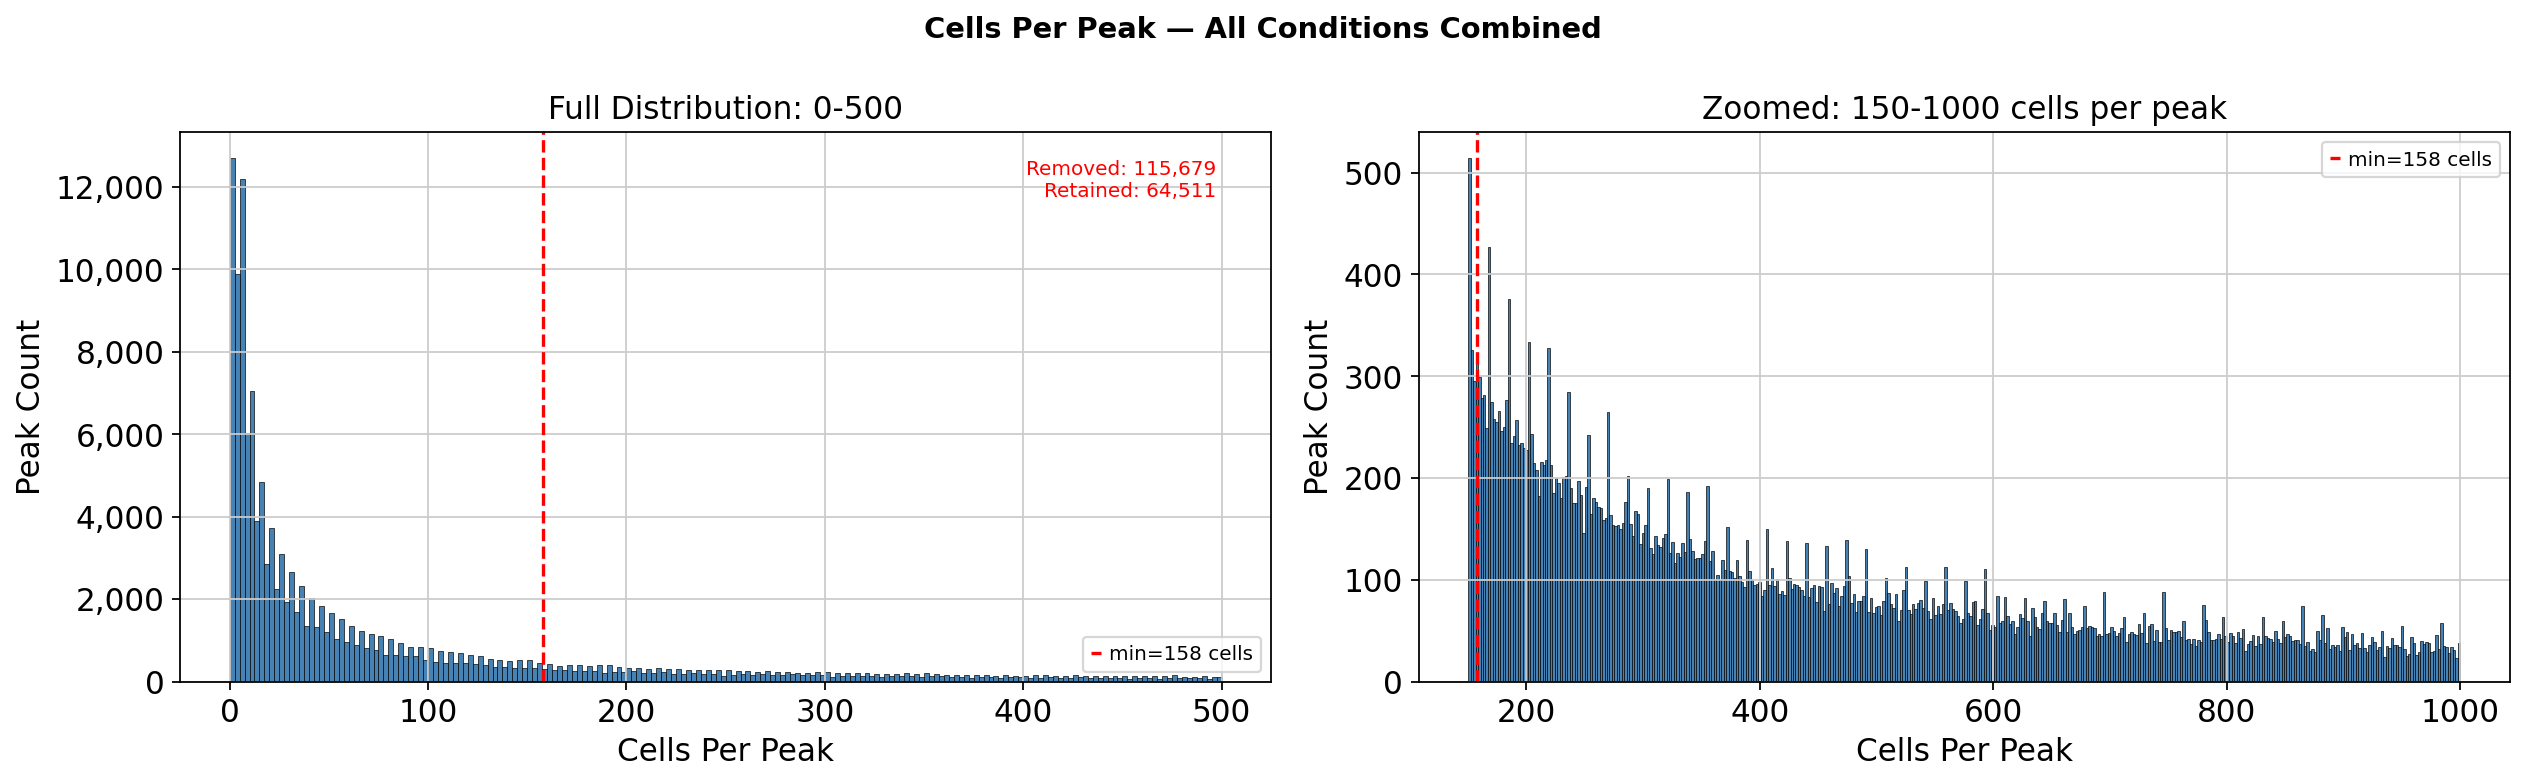

NK_SFD: 180,190 → 64,511 peaks (115,679 removed)
NK_HFD: 180,190 → 64,511 peaks (115,679 removed)
NK_GLP: 180,190 → 64,511 peaks (115,679 removed)
NK_CR: 180,190 → 64,511 peaks (115,679 removed)


In [66]:
import anndata as ad

# Step 1: concatenate
atac_combined = ad.concat(
    [sc.read_h5ad(final_dir + f'{name}_atac_final.h5ad') for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']],
    join='outer'
)

# Step 2: compute cells per peak on combined
n_cells_per_peak_combined = np.asarray((atac_combined.X > 0).sum(axis=0)).flatten()
min_cells = 158
keep_peaks = atac_combined.var_names[n_cells_per_peak_combined >= min_cells]
n_removed  = atac_combined.n_vars - len(keep_peaks)
print(f"Retained: {len(keep_peaks):,} / {atac_combined.n_vars:,} ({n_removed:,} removed)")

# Step 3: histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cells Per Peak — All Conditions Combined', fontsize=13, fontweight='bold')

# left: full 0-500
axes[0].hist(n_cells_per_peak_combined, bins=200, range=(0, 500),
             color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].axvline(min_cells, c='r', linestyle='--', label=f'min={min_cells} cells')
axes[0].set_xlabel('Cells Per Peak')
axes[0].set_ylabel('Peak Count')
axes[0].set_title('Full Distribution: 0-500')
axes[0].legend(fontsize=9)
axes[0].text(0.95, 0.95, f'Removed: {n_removed:,}\nRetained: {len(keep_peaks):,}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9, color='red')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

# right: zoomed 150-1000 around threshold
axes[1].hist(n_cells_per_peak_combined, bins=400, range=(150, 1000),
             color='steelblue', edgecolor='black', linewidth=0.3)
axes[1].axvline(min_cells, c='r', linestyle='--', label=f'min={min_cells} cells')
axes[1].set_xlabel('Cells Per Peak')
axes[1].set_ylabel('Peak Count')
axes[1].set_title('Zoomed: 150-1000 cells per peak')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
plt.tight_layout()
plt.savefig(final_dir + 'peak_quality_histogram_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 4: apply unified peak mask per sample
for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    atac      = sc.read_h5ad(final_dir + f'{name}_atac_final.h5ad')
    atac_filt = atac[:, atac.var_names.isin(keep_peaks)].copy()
    atac_filt.write_h5ad(final_dir + f'{name}_atac_peak_filtered.h5ad')
    print(f"{name}: {atac.n_vars:,} → {atac_filt.n_vars:,} peaks ({atac.n_vars - atac_filt.n_vars:,} removed)")

=== Peak retention by study ===
lau2018              total=86,127  retained=55,388  removed=30,739  (64.3% retained)
pedde2024            total=90,741  retained=54,795  removed=35,946  (60.4% retained)
shih2016             total=77,464  retained=53,087  removed=24,377  (68.5% retained)
wiedemann2021        total=59,600  retained=43,499  removed=16,101  (73.0% retained)
wiedemann2021b       total=87,251  retained=56,711  removed=30,540  (65.0% retained)
yoshida2019          total=69,009  retained=48,301  removed=20,708  (70.0% retained)


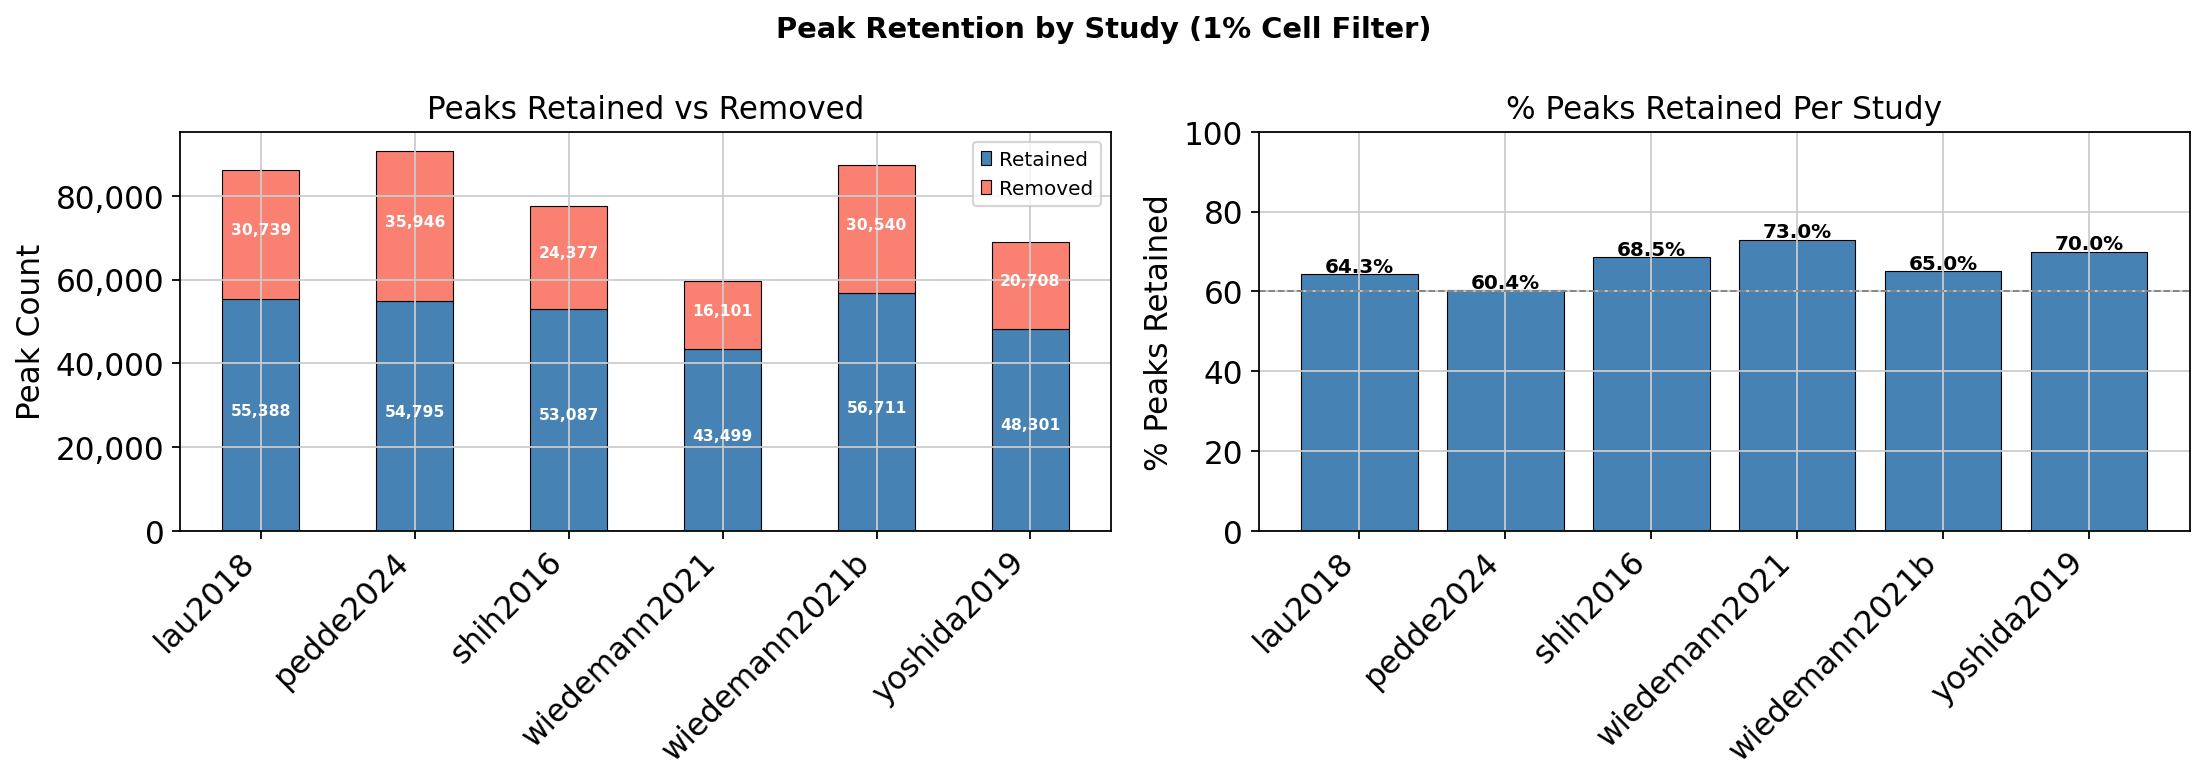

In [67]:
# load atlas metadata
atlas_meta = pd.read_csv('/Genomics/pritykinlab/seth/ATACCompendium/archived_atlas_outputs/all_atac_peaks.tsv', sep='\t')
atlas_meta.index = atlas_meta['name']

studies = ['lau2018', 'pedde2024', 'shih2016', 'wiedemann2021', 'wiedemann2021b', 'yoshida2019']

# compute retention stats
records = []
print("=== Peak retention by study ===")
for study in studies:
    study_peaks    = atlas_meta[atlas_meta[study] == True]['name']
    study_retained = [p for p in study_peaks if p in keep_peaks]
    study_removed  = len(study_peaks) - len(study_retained)
    pct_retained   = 100 * len(study_retained) / max(len(study_peaks), 1)
    print(f"{study:<20} total={len(study_peaks):>6,}  retained={len(study_retained):>6,}  "
          f"removed={study_removed:>6,}  ({pct_retained:.1f}% retained)")
    records.append({
        'study':    study,
        'total':    len(study_peaks),
        'retained': len(study_retained),
        'removed':  study_removed,
        'pct':      pct_retained,
    })

df = pd.DataFrame(records)

# bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Peak Retention by Study (1% Cell Filter)', fontsize=13, fontweight='bold')

x     = np.arange(len(studies))
width = 0.5

# left: stacked bar retained vs removed
axes[0].bar(x, df['retained'], width, label='Retained', color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].bar(x, df['removed'],  width, bottom=df['retained'], label='Removed', color='salmon', edgecolor='black', linewidth=0.5)

for i, row in df.iterrows():
    axes[0].text(i, row['retained']/2,
                 f'{row["retained"]:,}', ha='center', fontsize=7, color='white', fontweight='bold')
    axes[0].text(i, row['retained'] + row['removed']/2,
                 f'{row["removed"]:,}', ha='center', fontsize=7, color='white', fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(studies, rotation=45, ha='right')
axes[0].set_ylabel('Peak Count')
axes[0].set_title('Peaks Retained vs Removed')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

# right: % retained
bars = axes[1].bar(df['study'], df['pct'], color='steelblue', edgecolor='black', linewidth=0.5)
for bar, p in zip(bars, df['pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{p:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticklabels(studies, rotation=45, ha='right')
axes[1].set_ylabel('% Peaks Retained')
axes[1].set_ylim(0, 100)
axes[1].set_title('% Peaks Retained Per Study')
axes[1].axhline(60, c='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(final_dir + 'peak_retention_by_study.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
import scanpy as sc
from scipy import sparse
import numpy as np

# Apply unified peak mask per sample (1% ArchR standard, combined filter)
for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    atac      = sc.read_h5ad(final_dir + f'{name}_atac_final.h5ad')
    atac_filt = atac[:, atac.var_names.isin(keep_peaks)].copy()
    atac_filt.write_h5ad(final_dir + f'{name}_atac_peak_filtered.h5ad')
    print(f"{name}: {atac.n_vars:,} → {atac_filt.n_vars:,} peaks ({atac.n_vars - atac_filt.n_vars:,} removed)")

NK_SFD: 180,190 → 64,511 peaks (115,679 removed)
NK_HFD: 180,190 → 64,511 peaks (115,679 removed)
NK_GLP: 180,190 → 64,511 peaks (115,679 removed)
NK_CR: 180,190 → 64,511 peaks (115,679 removed)
